# Burgers Dataset - Exploratory Data Analysis

This notebook is AI-Generated.

Exploring the `BurgersGenerator` dataset from `flowpde.datasets.exponax.burgers`.

The generator produces initial-condition -> final-state pairs for the periodic Burgers equation

$$\partial_t u + c\,u\,\partial_x u = \nu\,\partial_{xx}u$$

where smooth random sine initial conditions are evolved with Exponax's spectral ETDRK stepper. Each sample can draw its own diffusivity $\nu$ from a log-uniform range.

This notebook covers:
1. Dataset generation and basic stats
2. Sample visualization of initial/final pairs
3. Value, norm, and diffusivity distributions
4. Spatial statistics along the periodic grid
5. Trajectory evolution through time
6. Spectral analysis
7. A numerical PDE residual sanity check
8. Effect of IC complexity and diffusivity
9. The inverse problem with partial, noisy observations
10. Field normalization for training

In [1]:
import sys
from pathlib import Path

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import torch
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.colors import TwoSlopeNorm
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
from flowpde.datasets.exponax.burgers import BurgersConfig, BurgersGenerator
from flowpde.datasets.normalization import FieldNormalizer

## 1. Generate the Dataset

Configure `BurgersConfig` and generate a forward dataset (`initial -> final`). We enable `store_trajectory=True` so later cells can inspect the rollout, not just the endpoint.

In [3]:
burgers_cfg = BurgersConfig(
    num_spatial_dims=1,
    num_points=128,
    domain_extent=1.0,
    num_samples=500,
    seed=42,
    dt=5e-4,
    num_steps=200,
    diffusivity_min=1e-3,
    diffusivity_max=1e-2,
    convection_scale=1.0,
    ic_num_terms=4,
    ic_max_mode=5,
    store_trajectory=True,
)

burgers_gen = BurgersGenerator(config=burgers_cfg)
burgers_dataset = burgers_gen.generate(problem='forward')

# Raw tensors: initial/final have shape (N, 1, X)
burgers_data = burgers_dataset.get_raw_data()
initial = burgers_data['initial'].numpy()
final = burgers_data['final'].numpy()
diffusivity = burgers_data['diffusivity'].numpy()
trajectory = burgers_data['trajectory'].numpy()  # (N, T+1, 1, X)

n_samples, _, X = initial.shape
T = burgers_cfg.dt * burgers_cfg.num_steps
x = np.linspace(0.0, burgers_cfg.domain_extent, X, endpoint=False)
times = np.arange(burgers_cfg.num_steps + 1) * burgers_cfg.dt

print(f"Config: {burgers_dataset.get_config()}")
print(f"\nData keys: {list(burgers_data.keys())}")
print(f"Initial shape:    {initial.shape}")
print(f"Final shape:      {final.shape}")
print(f"Diffusivity shape:{diffusivity.shape}")
print(f"Trajectory shape: {trajectory.shape}")
print(f"Final time T:     {T:.4f}")

Generated Burgers 1D dataset: 500 samples, 128 grid, 200 steps (dt=0.0005), nu ~ LogUniform(1e-03, 1e-02)
Config: {'num_spatial_dims': 1, 'num_points': 128, 'domain_extent': 1.0, 'num_samples': 500, 'seed': 42, 'torch_device': 'cpu', 'obs_noise_std': 0.0, 'obs_mask_fraction': 1.0, 'dt': 0.0005, 'num_steps': 200, 'diffusivity_min': 0.001, 'diffusivity_max': 0.01, 'convection_scale': 1.0, 'single_channel': False, 'ic_num_terms': 4, 'ic_max_mode': 5, 'store_trajectory': True}

Data keys: ['initial', 'final', 'diffusivity', 'trajectory']
Initial shape:    (500, 1, 128)
Final shape:      (500, 1, 128)
Diffusivity shape:(500,)
Trajectory shape: (500, 201, 1, 128)
Final time T:     0.1000


## 2. Basic Statistics

Dataset-level statistics come pre-computed on `burgers_dataset.get_stats()`. We also compute per-sample $L^2$ norms and the endpoint change $\|u(T)-u(0)\|_2$.

In [4]:
stats = burgers_dataset.get_stats()
for field, s in stats.items():
    print(f"{field:>12s}:  mean={s['mean']:+.4f}  std={s['std']:.4f}  "
          f"min={s['min']:+.4f}  max={s['max']:.4f}")

initial_norms = np.linalg.norm(initial.reshape(n_samples, -1), axis=-1)
final_norms = np.linalg.norm(final.reshape(n_samples, -1), axis=-1)
delta_norms = np.linalg.norm((final - initial).reshape(n_samples, -1), axis=-1)

print(f"\nPer-sample ||initial||_2: mean={initial_norms.mean():.3f}  std={initial_norms.std():.3f}")
print(f"Per-sample ||final||_2:   mean={final_norms.mean():.3f}  std={final_norms.std():.3f}")
print(f"Per-sample ||delta||_2:   mean={delta_norms.mean():.3f}  std={delta_norms.std():.3f}")
print(f"\nnu range: [{diffusivity.min():.2e}, {diffusivity.max():.2e}]")
print(f"Mean mass drift per sample: "
      f"{(final[:, 0].mean(axis=-1) - initial[:, 0].mean(axis=-1)).mean():+.2e}")

     initial:  mean=+0.0000  std=0.7002  min=-2.9093  max=3.0873
       final:  mean=+0.0000  std=0.5214  min=-2.3375  max=2.3486
 diffusivity:  mean=+0.0039  std=0.0025  min=+0.0010  max=0.0099
  trajectory:  mean=+0.0000  std=0.6195  min=-3.1309  max=3.1199

Per-sample ||initial||_2: mean=7.337  std=2.987
Per-sample ||final||_2:   mean=5.494  std=2.148
Per-sample ||delta||_2:   mean=4.544  std=2.726

nu range: [1.01e-03, 9.87e-03]
Mean mass drift per sample: -4.18e-11


## 3. Sample Visualization

The initial condition is a smooth sine mixture. The final state reflects nonlinear advection from $u\partial_x u$ plus viscous smoothing from $\nu\partial_{xx}u$.

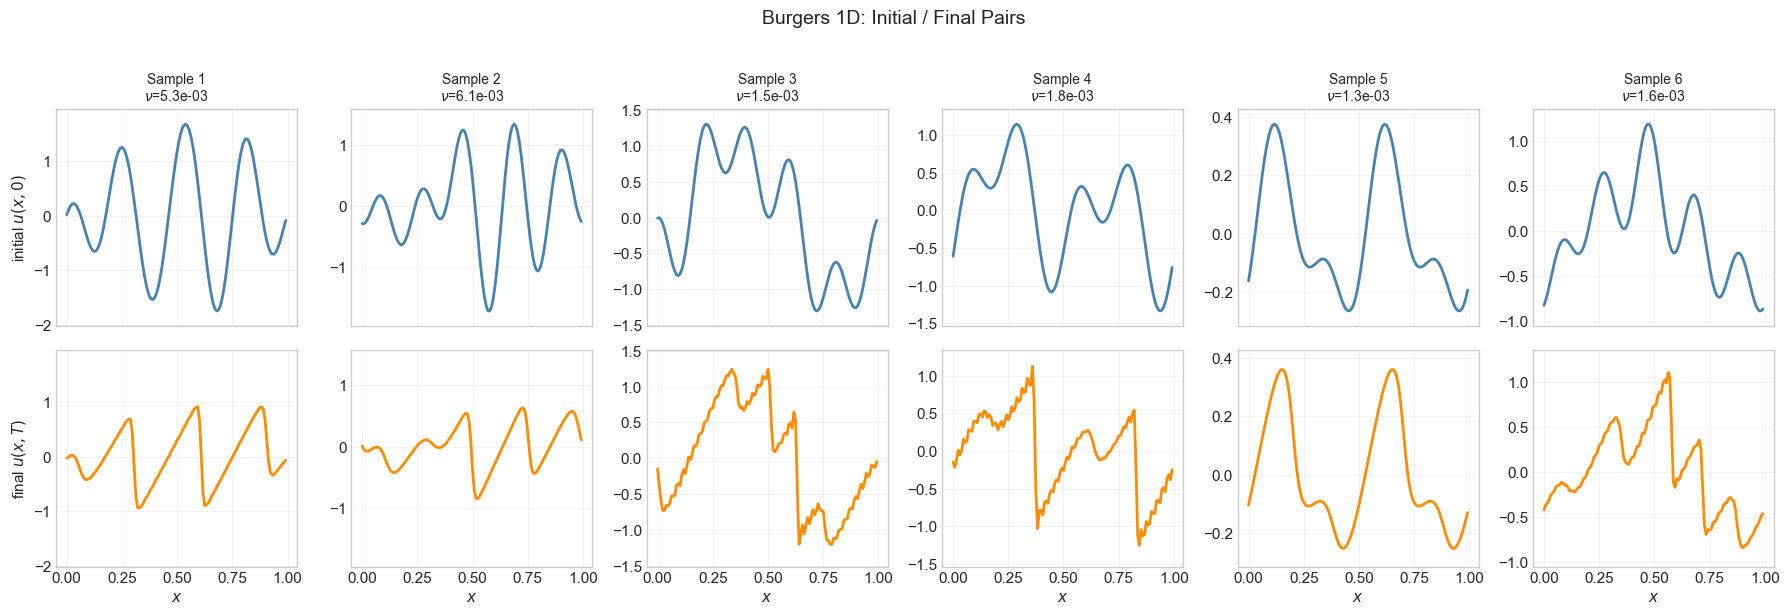

In [5]:
n_show = 6
fig, axes = plt.subplots(2, n_show, figsize=(3 * n_show, 6), sharex=True)

for i in range(n_show):
    u0 = initial[i, 0]
    uT = final[i, 0]
    ymin = min(u0.min(), uT.min())
    ymax = max(u0.max(), uT.max())
    pad = 0.08 * (ymax - ymin + 1e-8)

    axes[0, i].plot(x, u0, color='steelblue', linewidth=2)
    axes[0, i].set_title(f"Sample {i+1}\n$\\nu$={diffusivity[i]:.1e}", fontsize=10)
    axes[0, i].set_ylim(ymin - pad, ymax + pad)
    axes[0, i].grid(alpha=0.25)

    axes[1, i].plot(x, uT, color='darkorange', linewidth=2)
    axes[1, i].set_ylim(ymin - pad, ymax + pad)
    axes[1, i].grid(alpha=0.25)
    axes[1, i].set_xlabel('$x$')

axes[0, 0].set_ylabel('initial $u(x,0)$')
axes[1, 0].set_ylabel('final $u(x,T)$')
plt.suptitle('Burgers 1D: Initial / Final Pairs', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. Value, Norm, and Diffusivity Distributions

Pixel-value histograms, per-sample norm distributions, and the sampled log-uniform viscosity distribution.

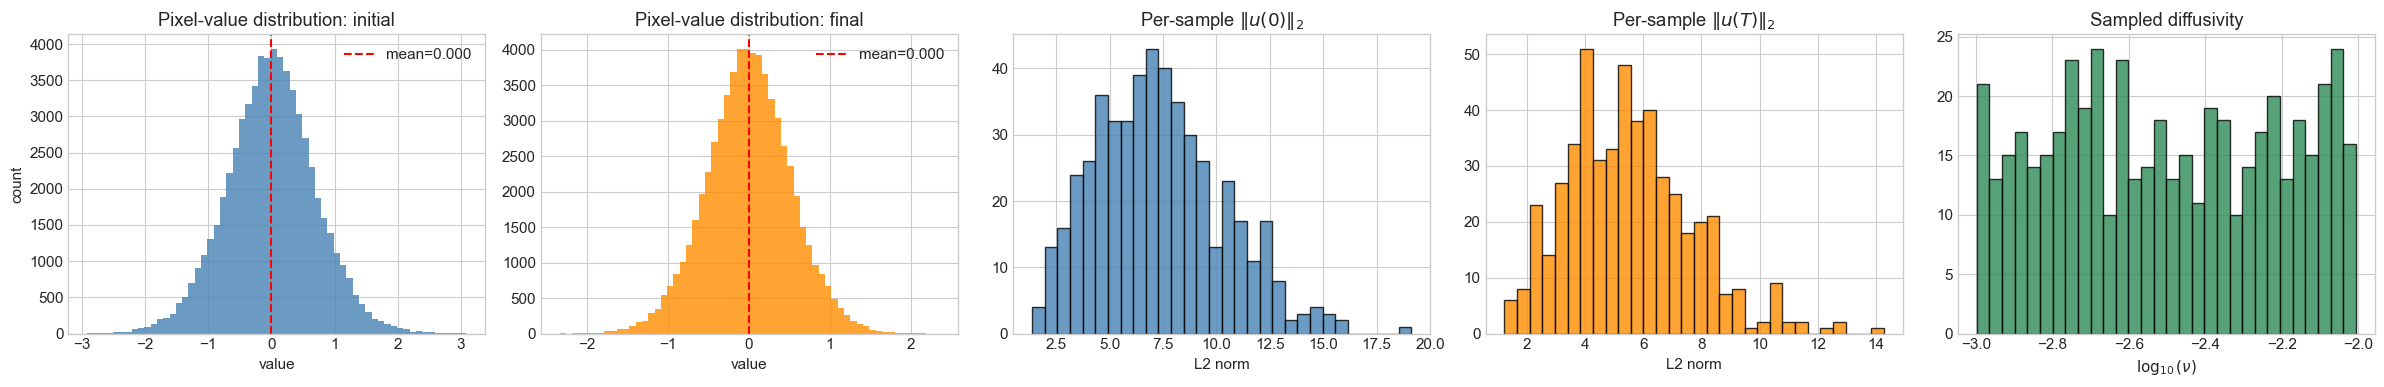

In [6]:
fig, axes = plt.subplots(1, 5, figsize=(24, 4))

axes[0].hist(initial.flatten(), bins=60, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].axvline(initial.mean(), color='red', linestyle='--', label=f'mean={initial.mean():.3f}')
axes[0].set_title('Pixel-value distribution: initial')
axes[0].set_xlabel('value')
axes[0].set_ylabel('count')
axes[0].legend()

axes[1].hist(final.flatten(), bins=60, color='darkorange', edgecolor='none', alpha=0.8)
axes[1].axvline(final.mean(), color='red', linestyle='--', label=f'mean={final.mean():.3f}')
axes[1].set_title('Pixel-value distribution: final')
axes[1].set_xlabel('value')
axes[1].legend()

axes[2].hist(initial_norms, bins=30, color='steelblue', edgecolor='black', alpha=0.8)
axes[2].set_title('Per-sample $\\|u(0)\\|_2$')
axes[2].set_xlabel('L2 norm')

axes[3].hist(final_norms, bins=30, color='darkorange', edgecolor='black', alpha=0.8)
axes[3].set_title('Per-sample $\\|u(T)\\|_2$')
axes[3].set_xlabel('L2 norm')

axes[4].hist(np.log10(diffusivity), bins=30, color='seagreen', edgecolor='black', alpha=0.8)
axes[4].set_title('Sampled diffusivity')
axes[4].set_xlabel('$\\log_{10}(\\nu)$')

plt.tight_layout()
plt.show()

## 5. Spatial Statistics - Point-wise Mean and Std

The random sine initial conditions are phase-shifted on a periodic domain, so the ensemble should be approximately homogeneous along $x$. Evolution should preserve that lack of preferred location.

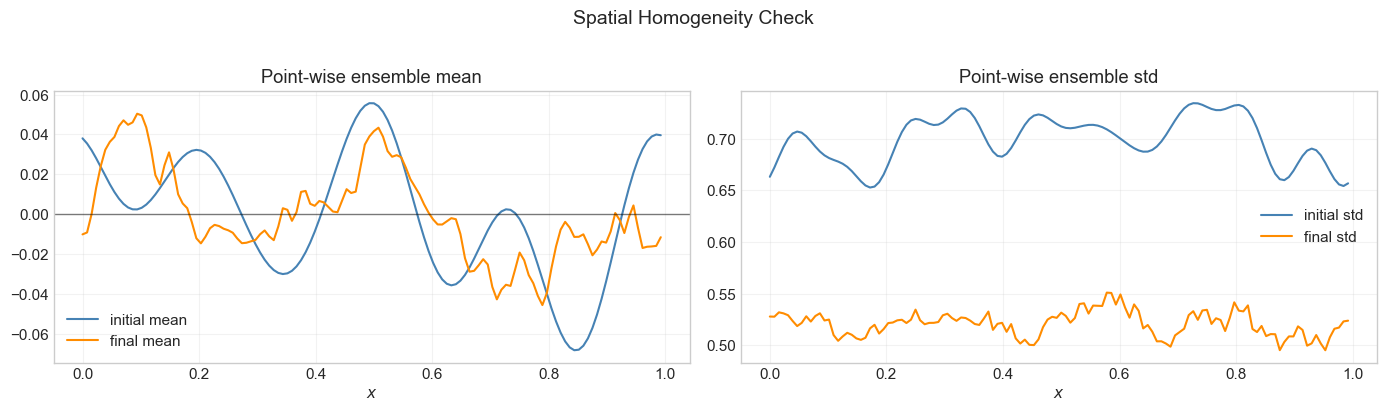

Std of mean curve - initial: 0.0311, final: 0.0225


In [7]:
initial_mean = initial[:, 0].mean(axis=0)
initial_std = initial[:, 0].std(axis=0)
final_mean = final[:, 0].mean(axis=0)
final_std = final[:, 0].std(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)

axes[0].plot(x, initial_mean, color='steelblue', label='initial mean')
axes[0].plot(x, final_mean, color='darkorange', label='final mean')
axes[0].axhline(0.0, color='black', linewidth=1, alpha=0.5)
axes[0].set_title('Point-wise ensemble mean')
axes[0].set_xlabel('$x$')
axes[0].legend()

axes[1].plot(x, initial_std, color='steelblue', label='initial std')
axes[1].plot(x, final_std, color='darkorange', label='final std')
axes[1].set_title('Point-wise ensemble std')
axes[1].set_xlabel('$x$')
axes[1].legend()

for ax in axes:
    ax.grid(alpha=0.25)

plt.suptitle('Spatial Homogeneity Check', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"Std of mean curve - initial: {initial_mean.std():.4f}, final: {final_mean.std():.4f}")

## 6. Trajectory Evolution

With `store_trajectory=True`, the dataset keeps the full rollout under key `trajectory`, shaped `(N, T+1, C, X)`. This makes it easy to inspect how advection steepens waves while diffusion damps high frequencies.

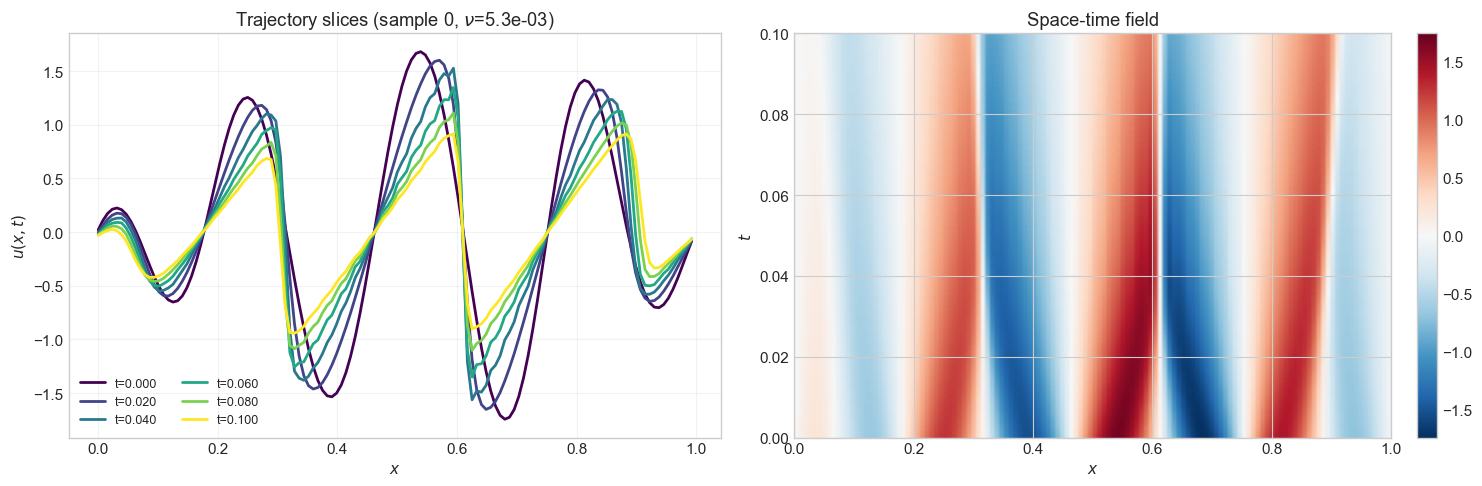

In [8]:
sample_idx = 0
traj = trajectory[sample_idx, :, 0]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

time_indices = np.linspace(0, burgers_cfg.num_steps, 6, dtype=int)
colors = plt.cm.viridis(np.linspace(0, 1, len(time_indices)))
for color, t_idx in zip(colors, time_indices):
    axes[0].plot(x, traj[t_idx], color=color, linewidth=2, label=f't={times[t_idx]:.3f}')
axes[0].set_title(f'Trajectory slices (sample {sample_idx}, $\\nu$={diffusivity[sample_idx]:.1e})')
axes[0].set_xlabel('$x$')
axes[0].set_ylabel('$u(x,t)$')
axes[0].legend(ncol=2, fontsize=9)
axes[0].grid(alpha=0.25)

im = axes[1].imshow(
    traj,
    aspect='auto',
    origin='lower',
    extent=[0, burgers_cfg.domain_extent, 0, T],
    cmap='RdBu_r',
    norm=TwoSlopeNorm(vcenter=0.0, vmin=-np.abs(traj).max(), vmax=np.abs(traj).max()),
)
axes[1].set_title('Space-time field')
axes[1].set_xlabel('$x$')
axes[1].set_ylabel('$t$')
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## 7. Spectral Analysis

The viscous term damps high frequencies, while the nonlinear convection term transfers energy between modes. Comparing initial and final spectra makes that visible.

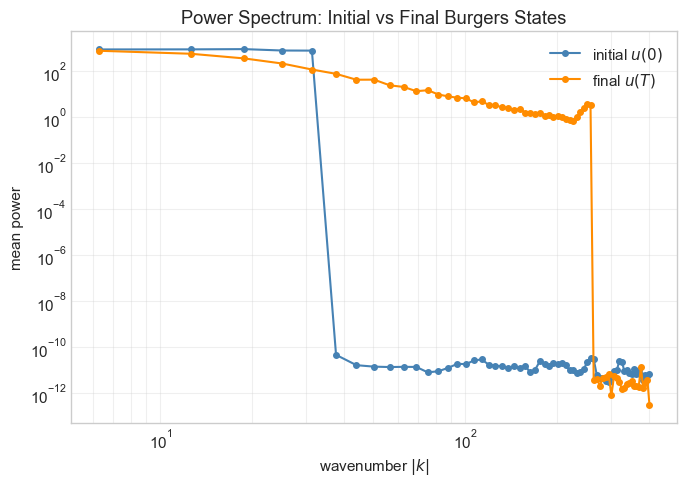

In [9]:
def one_dimensional_power_spectrum(fields, domain_extent):
    """Average 1D power spectrum over samples.

    fields: (N, X) real array.
    Returns positive angular wavenumbers and mean power.
    """
    X = fields.shape[-1]
    fft = np.fft.rfft(fields, axis=-1)
    power = (np.abs(fft) ** 2).mean(axis=0)
    k = 2 * np.pi * np.fft.rfftfreq(X, d=domain_extent / X)
    return k, power


k0, p0 = one_dimensional_power_spectrum(initial[:, 0], burgers_cfg.domain_extent)
kT, pT = one_dimensional_power_spectrum(final[:, 0], burgers_cfg.domain_extent)

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(k0[1:], p0[1:], 'o-', color='steelblue', label='initial $u(0)$', markersize=4)
ax.loglog(kT[1:], pT[1:], 'o-', color='darkorange', label='final $u(T)$', markersize=4)
ax.set_xlabel('wavenumber $|k|$')
ax.set_ylabel('mean power')
ax.set_title('Power Spectrum: Initial vs Final Burgers States')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Sanity Check - Does the Trajectory Satisfy Burgers' Equation?

We independently compute a spectral spatial derivative and a centered finite-difference time derivative on the stored trajectory. This is a diagnostic check, so the residual is expected to be small relative to the signal but not exact machine precision: the Exponax stepper advances the PDE in discrete time.

RMS residual:        1.114e+01
Relative RMS residual:6.095e-01
Max |residual|:      2.373e+02


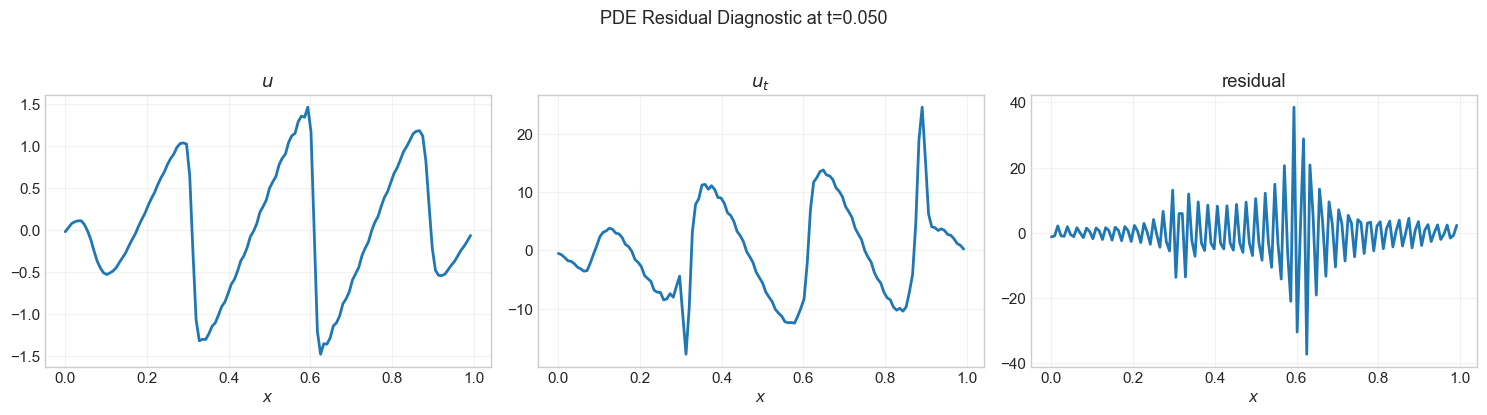

In [10]:
def spectral_derivatives_1d(u, domain_extent):
    """Return u_x and u_xx for arrays shaped (..., X)."""
    X = u.shape[-1]
    k = 2 * np.pi * np.fft.fftfreq(X, d=domain_extent / X)
    u_hat = np.fft.fft(u, axis=-1)
    ux = np.fft.ifft(1j * k * u_hat, axis=-1).real
    uxx = np.fft.ifft(-(k ** 2) * u_hat, axis=-1).real
    return ux, uxx


# Use a subset to keep this cell light.
subset = min(32, n_samples)
u = trajectory[:subset, :, 0]
u_mid = u[:, 1:-1]
u_t = (u[:, 2:] - u[:, :-2]) / (2 * burgers_cfg.dt)
u_x, u_xx = spectral_derivatives_1d(u_mid, burgers_cfg.domain_extent)
nu = diffusivity[:subset, None, None]

residual = u_t + burgers_cfg.convection_scale * u_mid * u_x - nu * u_xx
signal_scale = np.sqrt(np.mean(u_t ** 2)) + np.sqrt(np.mean((nu * u_xx) ** 2)) + 1e-8

print(f"RMS residual:        {np.sqrt(np.mean(residual ** 2)):.3e}")
print(f"Relative RMS residual:{np.sqrt(np.mean(residual ** 2)) / signal_scale:.3e}")
print(f"Max |residual|:      {np.abs(residual).max():.3e}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
check_sample = 0
check_time = burgers_cfg.num_steps // 2
fields = [
    (u_mid[check_sample, check_time - 1], '$u$'),
    (u_t[check_sample, check_time - 1], '$u_t$'),
    (residual[check_sample, check_time - 1], 'residual'),
]

for ax, (field, title) in zip(axes, fields):
    ax.plot(x, field, linewidth=2)
    ax.set_title(title)
    ax.set_xlabel('$x$')
    ax.grid(alpha=0.25)

plt.suptitle(f'PDE Residual Diagnostic at t={times[check_time]:.3f}', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

## 9. Effect of `ic_max_mode`, `ic_num_terms`, and Diffusivity

`ic_max_mode` and `ic_num_terms` control the complexity of the initial condition. Diffusivity $\nu$ controls how aggressively the equation damps high-frequency structure.

Generated Burgers 1D dataset: 4 samples, 128 grid, 200 steps (dt=0.0005), nu ~ LogUniform(3e-03, 3e-03)
Generated Burgers 1D dataset: 4 samples, 128 grid, 200 steps (dt=0.0005), nu ~ LogUniform(3e-03, 3e-03)
Generated Burgers 1D dataset: 4 samples, 128 grid, 200 steps (dt=0.0005), nu ~ LogUniform(3e-03, 3e-03)


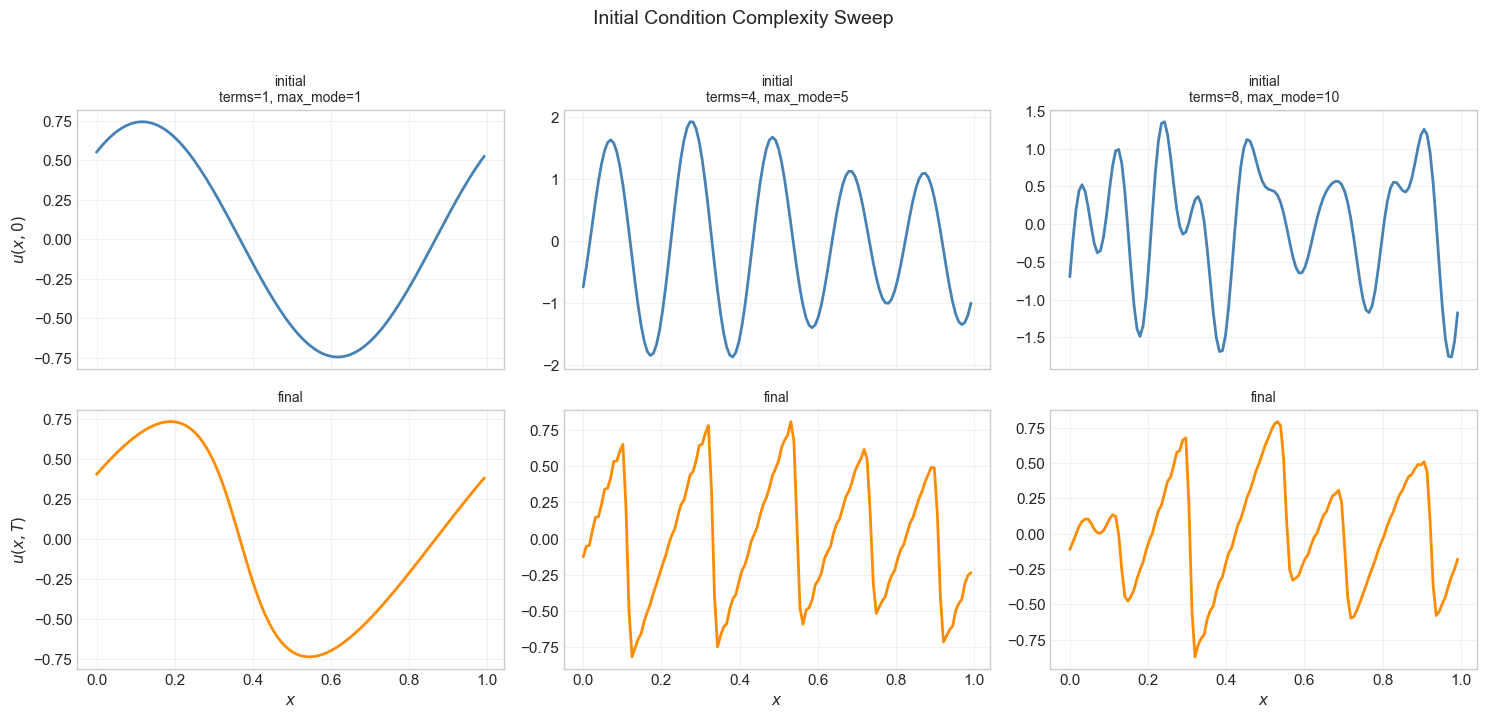

In [11]:
complexity_configs = [
    dict(ic_num_terms=1, ic_max_mode=1, label='terms=1, max_mode=1'),
    dict(ic_num_terms=4, ic_max_mode=5, label='terms=4, max_mode=5'),
    dict(ic_num_terms=8, ic_max_mode=10, label='terms=8, max_mode=10'),
]

fig, axes = plt.subplots(2, len(complexity_configs), figsize=(5 * len(complexity_configs), 7), sharex=True)

for j, sweep in enumerate(complexity_configs):
    cfg_j = BurgersConfig(
        num_spatial_dims=1, num_points=128, domain_extent=1.0,
        num_samples=4, seed=0,
        dt=5e-4, num_steps=200,
        diffusivity_min=3e-3, diffusivity_max=3e-3,
        ic_num_terms=sweep['ic_num_terms'], ic_max_mode=sweep['ic_max_mode'],
    )
    ds_j = BurgersGenerator(config=cfg_j).generate()
    d_j = ds_j.get_raw_data()
    u0_j = d_j['initial'][0, 0].numpy()
    uT_j = d_j['final'][0, 0].numpy()

    axes[0, j].plot(x, u0_j, color='steelblue', linewidth=2)
    axes[0, j].set_title(f"initial\n{sweep['label']}", fontsize=10)
    axes[0, j].grid(alpha=0.25)

    axes[1, j].plot(x, uT_j, color='darkorange', linewidth=2)
    axes[1, j].set_title('final', fontsize=10)
    axes[1, j].set_xlabel('$x$')
    axes[1, j].grid(alpha=0.25)

axes[0, 0].set_ylabel('$u(x,0)$')
axes[1, 0].set_ylabel('$u(x,T)$')
plt.suptitle('Initial Condition Complexity Sweep', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Generated Burgers 1D dataset: 1 samples, 128 grid, 200 steps (dt=0.0005), nu ~ LogUniform(1e-04, 1e-04)
Generated Burgers 1D dataset: 1 samples, 128 grid, 200 steps (dt=0.0005), nu ~ LogUniform(1e-03, 1e-03)


/Users/sarperyurtseven/Desktop/sarper/FlowPDE/flowpde/datasets/exponax/utilities.py:76: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/native/ReduceOps.cpp:1879.)
  'std': tensor.std().item(),


Generated Burgers 1D dataset: 1 samples, 128 grid, 200 steps (dt=0.0005), nu ~ LogUniform(1e-02, 1e-02)


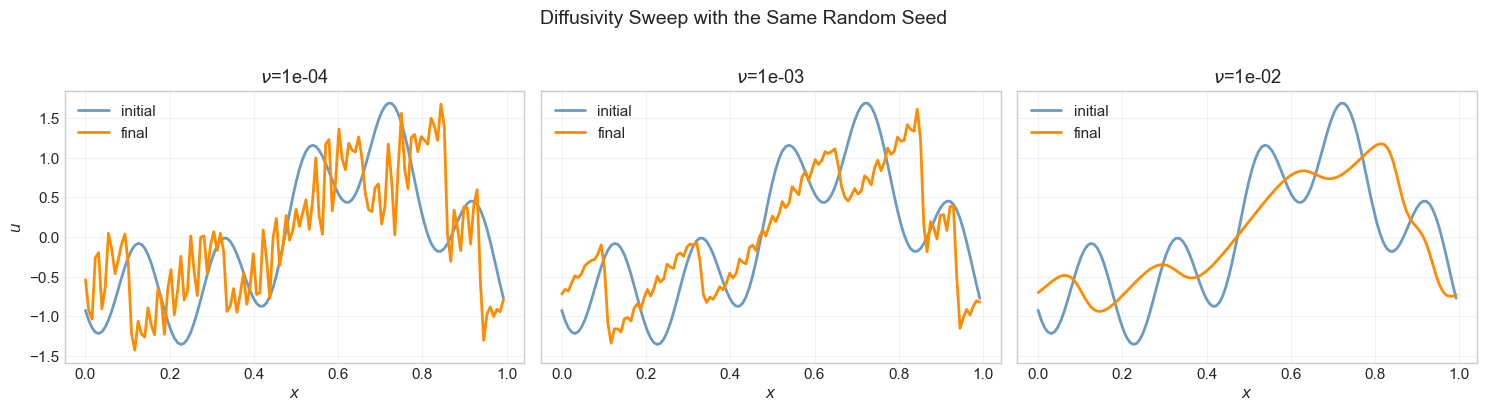

In [12]:
nu_values = [1e-4, 1e-3, 1e-2]
fig, axes = plt.subplots(1, len(nu_values), figsize=(5 * len(nu_values), 4), sharex=True, sharey=True)

for ax, nu_value in zip(axes, nu_values):
    cfg_nu = BurgersConfig(
        num_spatial_dims=1, num_points=128, domain_extent=1.0,
        num_samples=1, seed=123,
        dt=5e-4, num_steps=200,
        diffusivity_min=nu_value, diffusivity_max=nu_value,
        ic_num_terms=4, ic_max_mode=6,
    )
    ds_nu = BurgersGenerator(config=cfg_nu).generate()
    d_nu = ds_nu.get_raw_data()
    u0_nu = d_nu['initial'][0, 0].numpy()
    uT_nu = d_nu['final'][0, 0].numpy()

    ax.plot(x, u0_nu, color='steelblue', linewidth=2, alpha=0.8, label='initial')
    ax.plot(x, uT_nu, color='darkorange', linewidth=2, label='final')
    ax.set_title(f'$\\nu$={nu_value:.0e}')
    ax.set_xlabel('$x$')
    ax.grid(alpha=0.25)
    ax.legend()

axes[0].set_ylabel('$u$')
plt.suptitle('Diffusivity Sweep with the Same Random Seed', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 10. Inverse Problem: Partial, Noisy Observations

For `problem='inverse'`, the roles flip: the model observes a noisy, partially masked final state $u(T)$ and must recover the initial condition $u(0)$. `obs_noise_std` adds Gaussian measurement noise and `obs_mask_fraction` controls what fraction of grid points are visible. `__getitem__` concatenates the binary mask onto the input as an extra channel.

Generated Burgers 1D dataset: 8 samples, 128 grid, 200 steps (dt=0.0005), nu ~ LogUniform(1e-03, 1e-02)
Data keys: ['initial', 'final', 'diffusivity', 'obs_mask']
input shape (obs + mask channels): torch.Size([2, 128])
target shape (initial):             torch.Size([1, 128])


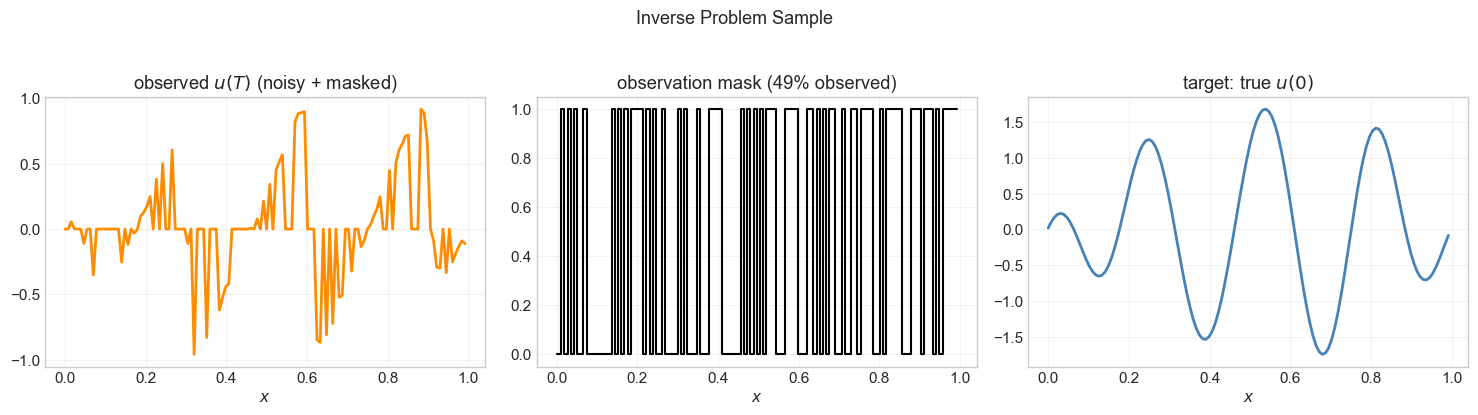

In [13]:
burgers_inv_cfg = BurgersConfig(
    num_spatial_dims=1, num_points=128, domain_extent=1.0,
    num_samples=8, seed=42,
    dt=5e-4, num_steps=200,
    diffusivity_min=1e-3, diffusivity_max=1e-2,
    ic_num_terms=4, ic_max_mode=5,
    obs_noise_std=0.02,
    obs_mask_fraction=0.4,
)
burgers_inv_ds = BurgersGenerator(config=burgers_inv_cfg).generate(problem='inverse')
inv_sample = burgers_inv_ds[0]

print(f"Data keys: {list(burgers_inv_ds.get_raw_data().keys())}")
print(f"input shape (obs + mask channels): {inv_sample['input'].shape}")
print(f"target shape (initial):             {inv_sample['target'].shape}")

obs_field = inv_sample['input'][0].numpy()
mask = inv_sample['obs_mask'][0].numpy()
target_initial = inv_sample['target'][0].numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
axes[0].plot(x, obs_field, color='darkorange', linewidth=2)
axes[0].set_title('observed $u(T)$ (noisy + masked)')

axes[1].step(x, mask, where='mid', color='black', linewidth=1.5)
axes[1].set_ylim(-0.05, 1.05)
axes[1].set_title(f'observation mask ({mask.mean() * 100:.0f}% observed)')

axes[2].plot(x, target_initial, color='steelblue', linewidth=2)
axes[2].set_title('target: true $u(0)$')

for ax in axes:
    ax.set_xlabel('$x$')
    ax.grid(alpha=0.25)

plt.suptitle('Inverse Problem Sample', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

## 11. Field Normalization

`initial` and `final` are close in scale but not identical, especially when diffusivity varies across samples. `FieldNormalizer` standardizes each field independently to zero mean / unit variance - fit on a training split and reused verbatim on val/test.

In [14]:
normalizer = FieldNormalizer.from_dataset(burgers_dataset)
burgers_dataset.set_normalizer(normalizer)

sample = burgers_dataset[0]
print(f"Fitted fields: {normalizer.fields}")
print(f"Raw    input  mean/std: {initial[0,0].mean():+.4f} / {initial[0,0].std():.4f}")
print(f"Normed input  mean/std: {sample['input'].mean():+.4f} / {sample['input'].std():.4f}")
print(f"Raw    target mean/std: {final[0,0].mean():+.4f} / {final[0,0].std():.4f}")
print(f"Normed target mean/std: {sample['target'].mean():+.4f} / {sample['target'].std():.4f}")

# Detach the normalizer again so later cells keep working with raw-scale data
burgers_dataset.set_normalizer(None)

Fitted fields: ['diffusivity', 'final', 'initial', 'trajectory']
Raw    input  mean/std: -0.0000 / 0.9423
Normed input  mean/std: -0.0000 / 1.3510
Raw    target mean/std: -0.0000 / 0.4997
Normed target mean/std: -0.0000 / 0.9623
